In [1]:
import yaml
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np

from thesis_project.models.keyword_spotting import KWSBase, KWSDynamic
from thesis_project.models.components.routers import GRURouter
from thesis_project.utils.paths import get_data_dir
from thesis_project.datasets import SpeechCommandsGoogle
from base_config_temp import cfg, noise_train_cfg, noise_eval_cfg
from thesis_project.training.key_word_spotting import CrossEntropyPlusRankLoss, fit_dynamic_model, validate_dynamic_model

In [2]:
maximum_useful_rank = 64
target_rank = 16
target_rank_normalized = (target_rank - 1) / (maximum_useful_rank - 1)
batch_size = 64

torch.manual_seed(42)
np.random.seed(42)

# Device selection: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    pin_memory = True
    num_workers = 16
    print("Using CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    pin_memory = False
    num_workers = 0
    print("Using MPS")
else:
    device = torch.device("cpu")
    pin_memory = False
    print("Using CPU")

Using MPS


In [15]:
loss_history = np.load('/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/2025-12-15_12-21-44/history.npy', allow_pickle=True).item()

In [16]:
loss_history

{'run_dir': 'model_runs/dynamic/2025-12-15_12-21-44',
 'config': {'epochs': 10, 'max_rank': 64},
 'epochs_log': [{'epoch': 1,
   'train_loss': 0.38644290029161965,
   'train_ce_loss': 0.33119483062290683,
   'train_rank_loss': 0.05548046826474624,
   'train_acc': 89.08260577568838,
   'train_mean_rank_normalized': 0.37253093777085566,
   'train_rank_variance': 0.004647971446301583,
   'train_expected_rank': 23.841980017334762,
   'best_train_loss': 0.38644290029161965,
   'rank_loss_weight': 1.0},
  {'epoch': 2,
   'train_loss': 0.38028846905806307,
   'train_ce_loss': 0.38037938034238233,
   'train_rank_loss': 5.2445081458596253e-05,
   'train_acc': 87.56480859637341,
   'train_mean_rank_normalized': 0.23976557186500108,
   'train_rank_variance': 0.0028671095640598085,
   'train_expected_rank': 15.34499659936007,
   'best_train_loss': 0.38028846905806307,
   'rank_loss_weight': 1.0},
  {'epoch': 3,
   'train_loss': 0.4193063558196765,
   'train_ce_loss': 0.4200541010400927,
   'train_

In [3]:
# Model
base_model = KWSBase(cfg).to(device)
router = GRURouter(
    input_dim=base_model.spectrogram_bins, #type: ignore
    fc_hidden_dim=128,
    gru_hidden_dim=64,
    num_gru_layers=1,
    max_rank=maximum_useful_rank,
    last_layer_bias_init= 4.0 # to bias towards full rank at start
    ).to(device)

model = KWSDynamic(base=base_model, router=router).to(device)
#model_path = "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/2025-12-15_11-43-03/best_model.pth"
model_path = "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/2025-12-15_12-21-44/best_model.pth"
ckpt = torch.load(model_path, map_location=device)

model.load_state_dict(ckpt["model_state"])
model.to(device)

/Users/christoffer/Documents/Thesis/thesis_project/src/thesis_project/models/components/layers/cpc.py:26: UserWarning: The operator 'aten::linalg_svd' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:15.)
  U, S, Vt = torch.linalg.svd(W, full_matrices=False)


KWSDynamic(
  (base): KWSBase(
    (spectrogram): SpectrogramBlock(
      (spec): Spectrogram()
      (db): AmplitudeToDB()
      (inv): InverseSpectrogram()
    )
    (frontend): LowRankPointwiseConv1d()
    (backbone): ModuleList(
      (0-2): 3 x ModuleList(
        (0): DDWS_Conv1d(
          (pw_layer_1): LowRankPointwiseConv1d()
          (act1): PReLU(num_parameters=1)
          (dropout1): Dropout(p=0.1, inplace=False)
          (norm1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (ddw_conv): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(2,), groups=128, bias=False)
          (chomp): Chomp()
          (act2): PReLU(num_parameters=1)
          (dropout2): Dropout(p=0.1, inplace=False)
          (norm2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (pw_layer_2): LowRankPointwiseConv1d()
        )
        (1): DDWS_Conv1d(
          (pw_layer_1): LowRankPointwiseConv1d()
      

In [4]:
# Loss function and optimizer
criterion = CrossEntropyPlusRankLoss(
    target_rank_normalized=target_rank_normalized,
    rank_loss_weight=1.0,
    rank_loss_mode="batch_mean_mse",
    rank_var_weight=0.1,
)
data_dir = get_data_dir()
val_set = SpeechCommandsGoogle(root=str(data_dir), subset="validation", download=True, **noise_eval_cfg.model_dump())
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, pin_memory = pin_memory, num_workers=num_workers)

Adding noise: 100%|██████████| 4515/4515 [00:20<00:00, 215.45sample/s]


In [5]:
# validation
VAL_SNR_VALUES = [-5, 0, 5, 10,15,float('inf')]
validation_results=validate_dynamic_model(
    model=model,
    val_loader=val_loader,
    criterion=criterion,
    device=device,
    snr_values=VAL_SNR_VALUES,
)


SNR=-5: loss=0.8036, acc=74.95%, mean_rnorm=0.3136, exp_rank=20.76, mode_rank=15


SNR=0: loss=0.5276, acc=83.88%, mean_rnorm=0.2565, exp_rank=17.16, mode_rank=15


SNR=5: loss=0.4022, acc=87.86%, mean_rnorm=0.2320, exp_rank=15.61, mode_rank=15


SNR=10: loss=0.3356, acc=90.43%, mean_rnorm=0.2270, exp_rank=15.30, mode_rank=15


SNR=15: loss=0.3016, acc=91.63%, mean_rnorm=0.2263, exp_rank=15.26, mode_rank=15


SNR=inf: loss=0.2588, acc=92.76%, mean_rnorm=0.2264, exp_rank=15.26, mode_rank=15


In [12]:
validation_results[5]

{'loss': 0.4021676079445371,
 'acc': 87.86267995570321,
 'mean_rank_normalized': 0.23196107689064338,
 'expected_rank': 15.613547844110533,
 'rank_hist': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  4044,
  132,
  45,
  30,
  22,
  18,
  7,
  24,
  21,
  19,
  18,
  23,
  15,
  7,
  5,
  4,
  6,
  2,
  4,
  1,
  4,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  4,
  12,
  16,
  16,
  9,
  5,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'rank_hist_bins': [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64],
 'rank_hist_probs': [0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.

In [6]:
import math
import matplotlib.pyplot as plt


def plot_snr_acc_rank(
    results: dict,
    *,
    title: str = "Validation: Accuracy and Rank vs SNR",
):
    """
    results: dict like:
      results[snr] = {
        "loss": ...,
        "acc": ... (percent),
        "mean_rank_normalized": ...,
        "expected_rank": ...
      }
    """

    # --- sort SNRs nicely ---
    def snr_sort_key(s):
        if s is None:
            return (2, 0.0)
        if isinstance(s, float) and math.isinf(s):
            return (1, 1e9)
        return (0, float(s))

    snrs = sorted(results.keys(), key=snr_sort_key)

    x, x_labels, acc, exp_rank = [], [], [], []

    for s in snrs:
        d = results[s]
        if s is None:
            x.append(float("inf"))
            x_labels.append("None")
        elif isinstance(s, float) and math.isinf(s):
            x.append(s)
            x_labels.append("inf")
        else:
            x.append(float(s))
            x_labels.append(str(s))

        acc.append(float(d["acc"]))
        exp_rank.append(float(d["expected_rank"]))

    # Replace inf for plotting
    finite_x = [v for v in x if math.isfinite(v)]
    if not finite_x:
        raise ValueError("No finite SNR values to plot.")
    inf_x_pos = max(finite_x) + 5.0
    x_plot = [inf_x_pos if not math.isfinite(v) else v for v in x]

    # --- colors ---
    acc_color = "tab:blue"
    rank_color = "tab:orange"

    # --- plot ---
    fig, ax1 = plt.subplots(figsize=(8.5, 4.8))

    # Accuracy curve
    l1 = ax1.plot(
        x_plot,
        acc,
        marker="o",
        linewidth=2.5,
        color=acc_color,
        label="Accuracy",
    )
    ax1.set_xlabel("SNR (dB)")
    ax1.set_ylabel("Accuracy (%)", color=acc_color)
    ax1.tick_params(axis="y", colors=acc_color)
    ax1.grid(True, which="both", alpha=0.3)

    # Rank curve
    ax2 = ax1.twinx()
    l2 = ax2.plot(
        x_plot,
        exp_rank,
        marker="s",
        linewidth=2.5,
        linestyle="--",
        color=rank_color,
        label="Expected Rank",
    )
    ax2.set_ylabel("Expected Rank", color=rank_color)
    ax2.tick_params(axis="y", colors=rank_color)

    # X ticks
    ax1.set_xticks(x_plot)
    ax1.set_xticklabels(x_labels)

    # Combined legend
    lines = l1 + l2
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="best")

    ax1.set_title(title)
    plt.tight_layout()
    plt.show()


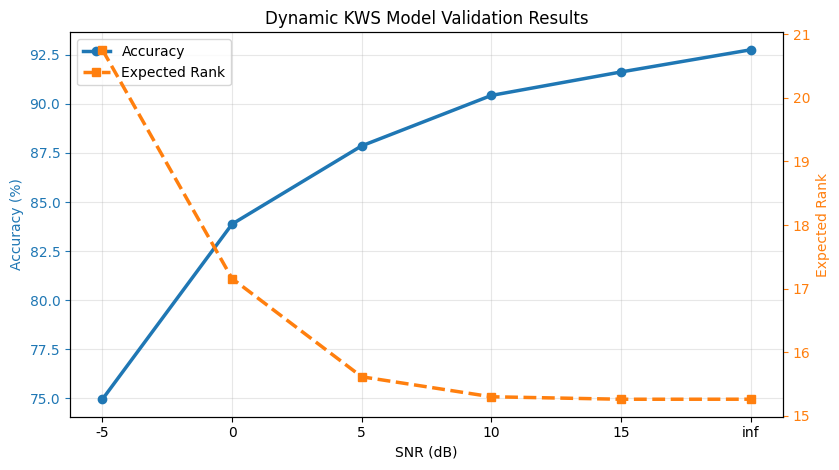

In [7]:
# Plot validation results
plot_snr_acc_rank(validation_results, title="Dynamic KWS Model Validation Results")

In [8]:
def plot_rank_histogram(
    results: dict,
    snr,
    *,
    max_rank: int = 64,
    normalize: bool = True,
    title: str | None = None,
):
    """
    Plot the rank histogram for a single SNR.

    Args:
        results:
            Output of validate_dynamic_model.
        snr:
            SNR key to plot (e.g. -5, 0, 5, 10, float("inf"), or None).
        max_rank:
            Maximum rank (number of bins).
        normalize:
            If True, plot probabilities; else plot raw counts.
        title:
            Optional custom title.
    """
    d = results[snr]

    hist = d["rank_hist"]
    bins = d.get("rank_hist_bins", list(range(1, max_rank + 1)))

    if normalize and "rank_hist_probs" in d:
        y = d["rank_hist_probs"]
        ylabel = "Probability"
    else:
        y = hist
        ylabel = "Count"

    x = bins

    plt.figure(figsize=(8, 3.5))
    plt.bar(x, y, width=0.8)
    plt.xlabel("Rank")
    plt.ylabel(ylabel)

    if title is None:
        title = f"Rank distribution at SNR={snr}"
    plt.title(title)

    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

In [9]:
def plot_rank_histograms_grid(
    results: dict,
    snrs: list,
    *,
    max_rank: int = 64,
    normalize: bool = True,
    n_cols: int = 2,
):
    """
    Plot rank histograms for multiple SNRs in a grid.

    Args:
        results:
            Output of validate_dynamic_model.
        snrs:
            List of SNR keys to plot (order matters).
        max_rank:
            Maximum rank.
        normalize:
            Plot probabilities if True, counts otherwise.
        n_cols:
            Number of columns in subplot grid.
    """
    n = len(snrs)
    n_rows = (n + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.5 * n_cols, 3.2 * n_rows),
        squeeze=False,
    )

    for ax, snr in zip(axes.flat, snrs):
        d = results[snr]
        hist = d["rank_hist"]
        bins = d.get("rank_hist_bins", list(range(1, max_rank + 1)))

        if normalize and "rank_hist_probs" in d:
            y = d["rank_hist_probs"]
            ylabel = "Probability"
        else:
            y = hist
            ylabel = "Count"

        ax.bar(bins, y, width=0.8)
        ax.set_title(f"SNR={snr}")
        ax.set_xlabel("Rank")
        ax.set_ylabel(ylabel)
        ax.grid(axis="y", alpha=0.3)

    # Hide unused axes
    for ax in axes.flat[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

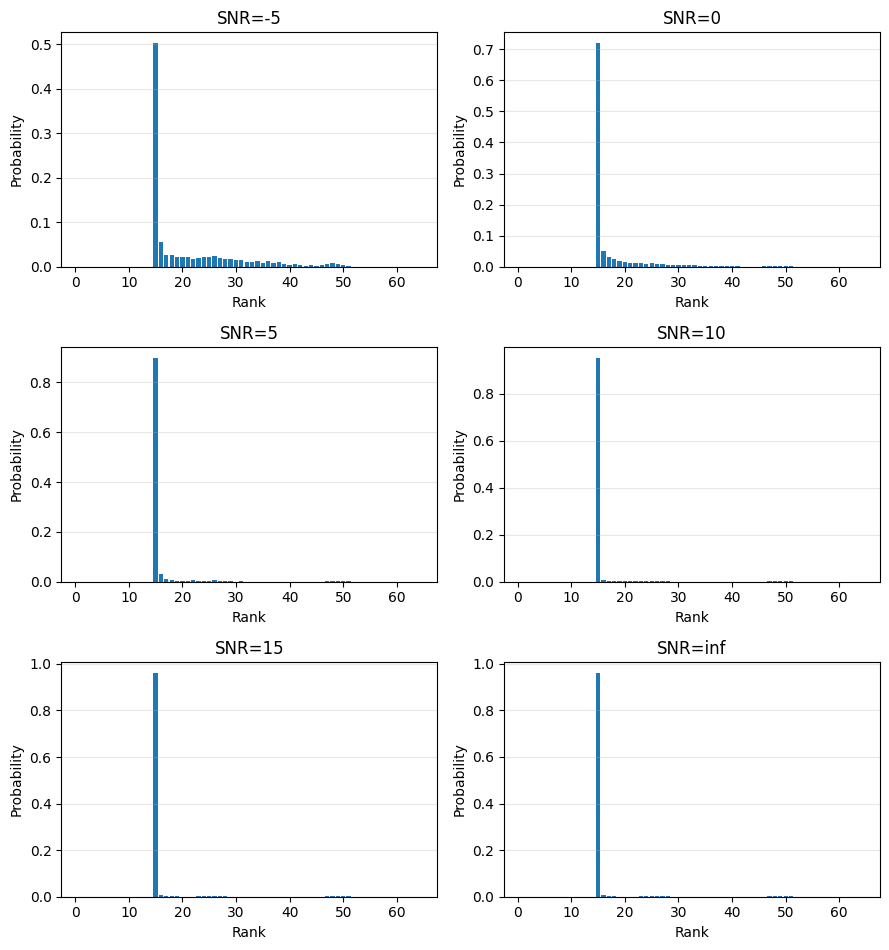

In [10]:
plot_rank_histograms_grid(results=validation_results, snrs=VAL_SNR_VALUES, max_rank=64)